# Dynamic Graph Evaluation

Reusable validation diagnostics for one saved dynamic-graph run. Change only `RUN_DIR` and the small display settings below.

Graph orientation is `A[target, source]`: rows receive information and columns send information.

In [1]:
from pathlib import Path
import sys

from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_candle_data import load_candle_splits, clean_candle_splits
from src.evaluation.dynamic_graph_evaluation import (
    plot_learned_graph,
    style_metrics_table,
    style_top_neighbours_table,
    style_model_summary_table,
    analyse_absolute_correlation_graph,
)

print("Project root:", PROJECT_ROOT)

DATA_DIR = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "Shared drives/Vishal/data/cached_datasets/"
    "exp-1m-95s-24y/session"
)

train_raw, val_raw, test_raw = load_candle_splits(DATA_DIR)

train, val, test = clean_candle_splits(
    train_raw,
    val_raw,
    test_raw,
)

Project root: /Users/vishalruparelia/Desktop/Thesis/dynamic_graphs_thesis


In [7]:
# Change this path to evaluate a different run.
RUN_DIR = Path(
    "/Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/"
    "My Drive/dissertation/final_model/initial_test/"
    "free_static_target_entropy_coarse_only_exponential_direct_head_short_stop"
)

print("Run directory:", RUN_DIR)

Run directory: /Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/final_model/initial_test/free_static_target_entropy_coarse_only_exponential_direct_head_short_stop


## Summarise Model

In [8]:
MODEL_SOURCE = "last"          # last | best

display(
    style_model_summary_table(
        RUN_DIR,
        source=MODEL_SOURCE,
    )
)

/Users/vishalruparelia/Library/Python/3.12/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


,Configuration
Component,
Temporal encoder,"Causal per-node Transformer (1 layer, 4 heads, d_model=64; repeated in 1 ST block)"
Graph learner,BaseDyGraph free-static direct edge logits (2 heads; activation=softmax; self-loops=off)
Spatial module,BaseDyGraph-style graph-weighted value aggregation (2 heads; residual + LayerNorm + FFN; 1 spatial layer per ST block; 1 ST block)
Output head,Direct parallel position-conditioned token head (final graph-aware state + learned future positions; future Transformer disabled)
Token target,Observed context uses s1+s2; predicts coarse s1 only (vocabulary=1024); coarse Kronos decode
Training loss,"s1 cross-entropy; exponential-decay future weights (half-life=5, floor=0.25); target-entropy regularisation (lambda=0.05, H*=2.2)"
Trainable parameters,"362,386 (0.362M; excludes frozen Kronos tokenizer/decoder)"


## Validation Metrics

In [9]:
METRICS_SOURCE = "best"        # best | last

display(
    style_metrics_table(
        RUN_DIR,
        source=METRICS_SOURCE,
        channel="close",
    )
)

,Log MAE,MASE,Rel. MAE,Win Rate,Pearson,IC,Rank IC,MMR,AbsRet Corr
Horizon,,,,,,,,,
1 min,0.00046072,1.151,1.21416,0.393067,0.000335574,0.0170239,0.0164593,0.617775,0.250442
5 min,0.000923474,2.31011,1.14727,0.416256,0.0382687,-0.000410918,-0.00389872,0.53813,0.190776
15 min,0.00164059,4.10843,1.13081,0.417898,0.0066453,-0.00789205,-0.00809056,0.504577,0.159905
30 min,0.00232463,5.83412,1.16352,0.405716,-0.00715927,-0.00404281,-0.00439247,0.56391,0.118189
60 min,0.00332408,8.33725,1.19165,0.396095,0.00821952,-0.00748516,5.10604e-05,0.64772,0.0828235


## Learned Graph

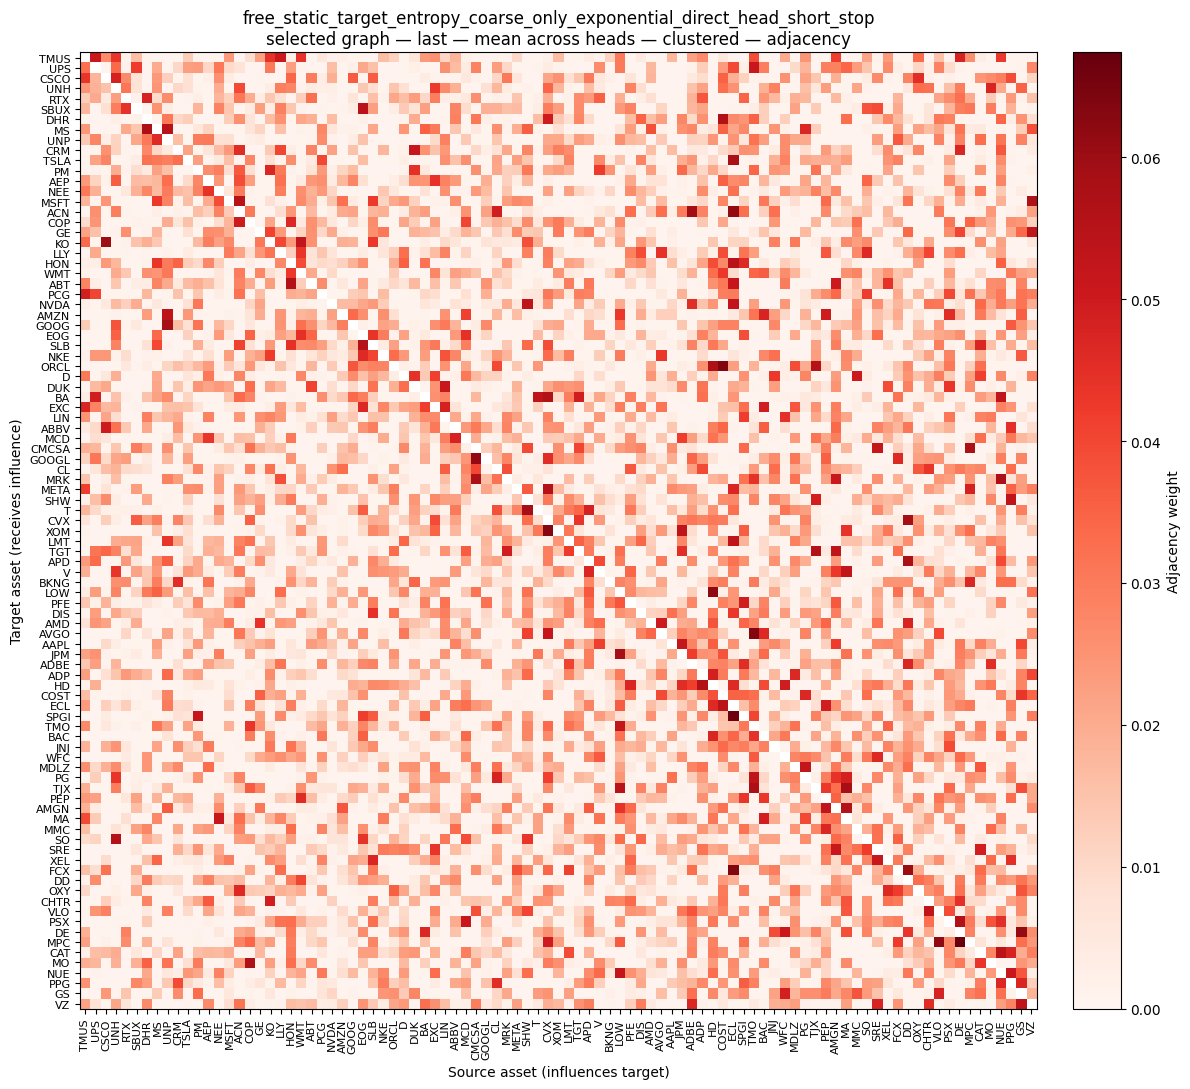

In [10]:
# Graph display settings.
GRAPH_SOURCE = "last"          # last | best | best_validation
GRAPH_COMPONENT = "selected"   # selected | base | dynamic
GRAPH_HEAD = "mean"            # mean or an integer head index

fig, ax, plotted_graph = plot_learned_graph(
    RUN_DIR,
    source=GRAPH_SOURCE,
    component=GRAPH_COMPONENT,
    head=GRAPH_HEAD,
    cluster=True,
    figsize=(13, 11),
    tick_fontsize=8,
    plot_adjacency=True,
)

## Top graph neighbours

In [11]:
# Neighbour-table settings.
TOP_N = 5
NEIGHBOUR_DIRECTION = "impacts"  # impacted_by | impacts

display(
    style_top_neighbours_table(
        RUN_DIR,
        top_n=TOP_N,
        direction=NEIGHBOUR_DIRECTION,
        source=GRAPH_SOURCE,
        component=GRAPH_COMPONENT,
        head=GRAPH_HEAD,
    )
)

,Neighbour 1,Weight 1,Neighbour 2,Weight 2,Neighbour 3,Weight 3,Neighbour 4,Weight 4,Neighbour 5,Weight 5
Stock,,,,,,,,,,
AAPL,DIS,0.032248,PG,0.031919,META,0.026679,CMCSA,0.025630,BAC,0.021772
ABBV,MCD,0.047708,MMC,0.033056,T,0.030231,ECL,0.029699,DHR,0.028701
ABT,DUK,0.040787,EOG,0.034073,RTX,0.032186,CSCO,0.029673,CRM,0.028497
ACN,MSFT,0.054512,COP,0.049681,OXY,0.046270,CRM,0.045544,SLB,0.040949
ADBE,ACN,0.059054,VZ,0.046841,NVDA,0.045388,JPM,0.041868,HD,0.041417
ADP,HD,0.056161,CL,0.039257,RTX,0.037160,BA,0.032277,MDLZ,0.031745
AEP,NEE,0.044400,MCD,0.043419,CHTR,0.036627,MDLZ,0.033003,BKNG,0.031100
AMD,MS,0.038396,AVGO,0.034351,SPGI,0.025021,D,0.024579,PM,0.022849
AMGN,TGT,0.053374,SRE,0.051114,MRK,0.050524,ABT,0.050212,PG,0.044075


## Analyse Correlation Graph

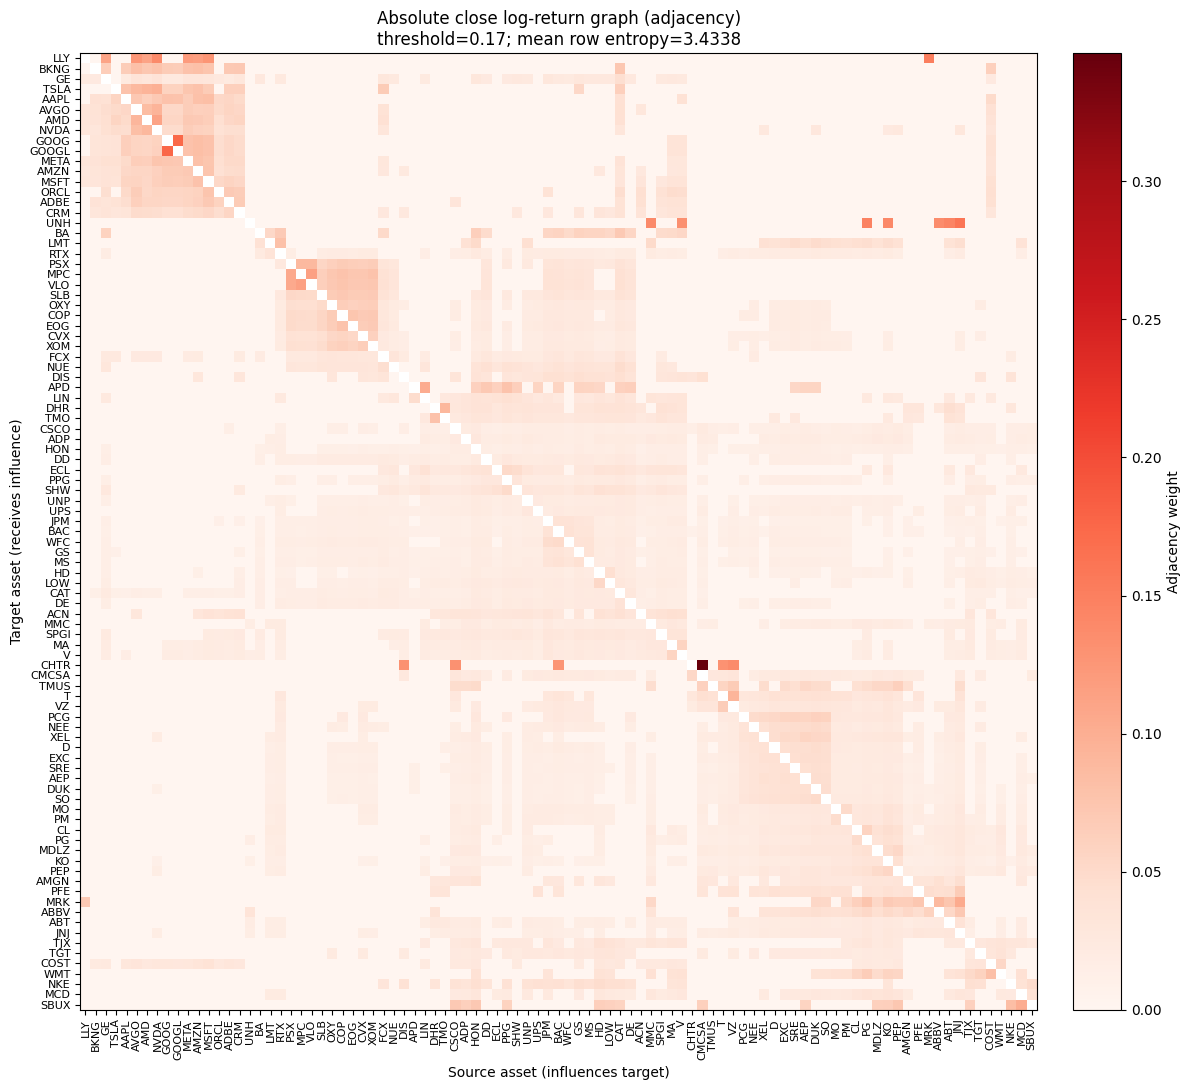

,Threshold,Assets,Mean retained neighbours,Min retained neighbours,Max retained neighbours,Mean row entropy,Mean effective neighbours
0,0.1700,93,36.22,6,68,3.4338,34.76


,Neighbour 1,Weight 1,Neighbour 2,Weight 2,Neighbour 3,Weight 3,Neighbour 4,Weight 4,Neighbour 5,Weight 5
Stock,,,,,,,,,,
AAPL,MSFT,0.082054,AMZN,0.078791,GOOG,0.077816,GOOGL,0.076644,AVGO,0.070548
ABBV,JNJ,0.070426,MRK,0.058623,AMGN,0.052457,ABT,0.052196,PG,0.051994
ABT,JNJ,0.036063,PG,0.028293,KO,0.026685,ABBV,0.025152,PEP,0.025013
ACN,MA,0.041979,V,0.041786,CAT,0.039550,CRM,0.038897,HD,0.038489
ADBE,MSFT,0.069624,CRM,0.066375,AVGO,0.061413,AMZN,0.059806,ORCL,0.058187
ADP,HON,0.028018,MMC,0.023565,PEP,0.023521,CSCO,0.023206,MDLZ,0.023017
AEP,DUK,0.045802,SO,0.043641,EXC,0.042483,SRE,0.041062,XEL,0.040757
AMD,NVDA,0.111616,AVGO,0.091896,META,0.069308,AMZN,0.067785,MSFT,0.064302
AMGN,JNJ,0.043476,ABBV,0.040713,HON,0.037443,PEP,0.034865,MRK,0.033824


In [15]:
correlation_result = analyse_absolute_correlation_graph(
    train,
    threshold=0.17,
    top_n=5,
    direction="impacted_by",
    plot_adjacency=True,
)

In [16]:
from pathlib import Path
import importlib

from IPython.display import display

import src.evaluation.dynamic_graph_evaluation as dge


dge = importlib.reload(
    dge
)

print(
    "Evaluation module:",
    dge.__file__,
)

print(
    "Evaluation module version:",
    dge.EVALUATION_MODULE_VERSION,
)

Evaluation module: /Users/vishalruparelia/Desktop/Thesis/dynamic_graphs_thesis/src/evaluation/dynamic_graph_evaluation.py
Evaluation module version: 2026-07-30-consolidated-v7-graph-reliance


In [26]:
RUN_DIR = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "My Drive/dissertation/final_model/initial_test/"
    "free_static_target_entropy_coarse_only_"
    "exponential_short_stop"
)

CHECKPOINT_SOURCE = "best"  # best | last

# 64 evenly spaced windows gives a reasonably broad September sample.
# Set to None for all 380 validation windows.
MAX_WINDOWS = None

# None automatically chooses CUDA, then MPS, then CPU.
DEVICE = None

# Start with False for the faster token-level analysis.
# Set to True to run every intervention through the frozen Kronos
# decoder and calculate decoded CLG-MAE.
DECODE_PRICES = True

In [18]:
branch_diagnostics = (
    dge.analyse_spatial_branch_reliance(
        RUN_DIR,
        source=CHECKPOINT_SOURCE,
        max_windows=MAX_WINDOWS,
        batch_size=2,
        device=DEVICE,
        block_index=0,
        spatial_layer_index=0,
    )
)

display(
    branch_diagnostics.summary.style
    .format(
        "{:.6f}",
        na_rep="—",
    )
    .set_caption(
        "Temporal residual versus graph-message branch"
    )
)

/Users/vishalruparelia/Library/Python/3.12/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


,Mean,Median,P10,P90
Metric,,,,
Temporal feature scale,1.280356,1.250451,1.086907,1.514476
Graph branch feature scale,0.446404,0.405957,0.269419,0.683349
Bias-free graph signal scale,0.453023,0.412833,0.267719,0.696897
Graph / temporal scale ratio,0.345380,0.326563,0.224643,0.493611
Temporal–graph cosine,0.025026,0.022180,-0.152352,0.201159
Post-mix LayerNorm graph effect RMS,0.323812,0.309667,0.217060,0.450209
Full spatial-layer graph effect RMS,0.323756,0.290042,0.180034,0.518530


In [19]:
display(
    branch_diagnostics.per_asset
    .sort_values(
        "Graph / temporal scale ratio",
        ascending=False,
    )
    .style
    .format(
        "{:.6f}",
        na_rep="—",
    )
    .set_caption(
        "Spatial-branch influence by asset"
    )
)

,Temporal feature scale,Graph branch feature scale,Bias-free graph signal scale,Graph / temporal scale ratio,Temporal–graph cosine,Post-mix LayerNorm graph effect RMS,Full spatial-layer graph effect RMS
Asset,,,,,,,
ADBE,1.270368,0.470714,0.480116,0.366901,0.027109,0.342156,0.346188
PFE,1.271428,0.462502,0.470150,0.361432,0.033695,0.337034,0.335181
BAC,1.290246,0.467821,0.476850,0.359240,0.020324,0.336767,0.341989
SO,1.267840,0.458501,0.465778,0.358747,0.018281,0.336658,0.335055
VZ,1.256937,0.453640,0.461607,0.358193,0.021051,0.336016,0.335716
ABT,1.254000,0.453315,0.460842,0.357820,0.010852,0.335959,0.336314
MPC,1.267838,0.457901,0.464588,0.357660,0.028943,0.334524,0.329744
VLO,1.266978,0.456252,0.464257,0.357411,0.023464,0.334318,0.339468
MS,1.275422,0.459269,0.468876,0.356750,0.009093,0.335811,0.335451


In [20]:
display(
    branch_diagnostics.per_context_position
    .style
    .format(
        "{:.6f}",
        na_rep="—",
    )
    .set_caption(
        "Spatial-branch influence by context minute"
    )
)

,Temporal feature scale,Graph branch feature scale,Bias-free graph signal scale,Graph / temporal scale ratio,Temporal–graph cosine,Post-mix LayerNorm graph effect RMS,Full spatial-layer graph effect RMS
Context minute,,,,,,,
1,1.684046,0.741951,0.757204,0.444618,-0.001163,0.411969,0.455789
2,1.574878,0.618438,0.623639,0.395465,0.073602,0.362898,0.376293
3,1.547034,0.631398,0.642146,0.410872,-0.009762,0.388120,0.410522
4,1.507407,0.741333,0.755510,0.495207,-0.000505,0.454882,0.497230
5,1.471177,0.622501,0.632753,0.425384,-0.002076,0.398184,0.419210
6,1.460029,0.648163,0.658044,0.445660,0.022082,0.410615,0.450496
7,1.431264,0.534056,0.550331,0.375235,0.060352,0.348294,0.366636
8,1.411673,0.576490,0.590658,0.410411,0.013972,0.384305,0.433163
9,1.388871,0.497449,0.507597,0.359591,0.022706,0.340104,0.374457


In [27]:
gate_diagnostics = (
    dge.analyse_graph_gate_sweep(
        RUN_DIR,
        source=CHECKPOINT_SOURCE,
        gammas=(
            0.0,
            0.25,
            0.50,
            0.75,
            1.0,
        ),
        max_windows=MAX_WINDOWS,
        batch_size=1,
        device=DEVICE,
        block_index=0,
        spatial_layer_index=0,
        decode=DECODE_PRICES,
        decode_series_batch_size=64,
    )
)

display(
    gate_diagnostics.summary.style
    .format(
        "{:.6f}",
        na_rep="—",
    )
    .set_caption(
        "Graph-message gate sweep"
    )
)

/Users/vishalruparelia/Library/Python/3.12/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


,Gamma,s1 accuracy,s1 argmax change vs actual,s1 logit RMS delta vs actual,Mean KL(actual || intervention),h1 CLG-MAE,h5 CLG-MAE,Mean h1/h5 CLG-MAE,Invalid candle rate (%)
Intervention,,,,,,,,,
gamma=0,0.000000,0.063881,0.241283,0.748881,0.067339,0.000473,0.000959,0.000716,25.602056
gamma=0.25,0.250000,0.065003,0.176540,0.515379,0.034163,0.000463,0.000946,0.000704,25.542775
gamma=0.5,0.500000,0.066085,0.114769,0.321104,0.013608,0.000456,0.000936,0.000696,25.508866
gamma=0.75,0.750000,0.066722,0.055789,0.152052,0.003036,0.000450,0.000929,0.000690,25.460291
gamma=1,1.000000,0.067084,0.000000,0.000000,0.000000,0.000447,0.000924,0.000686,25.402424


In [28]:
display(
    gate_diagnostics.per_horizon.style
    .format(
        "{:.6f}",
        na_rep="—",
    )
    .set_caption(
        "Graph-message gate sweep by horizon"
    )
)

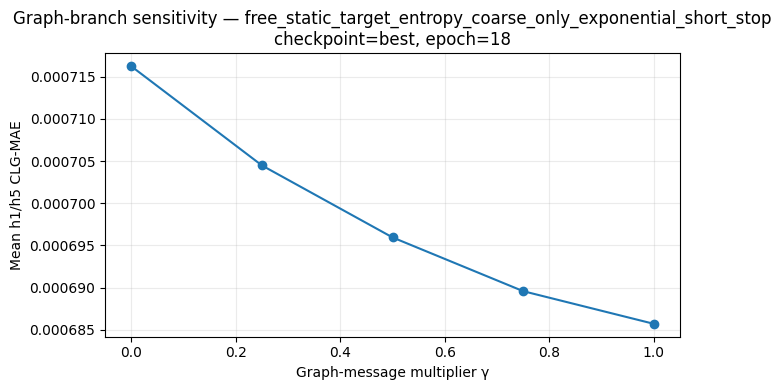

In [29]:
fig, ax = dge.plot_graph_gate_sweep(
    gate_diagnostics,
    metric="Mean h1/h5 CLG-MAE",
)

In [30]:
topology_diagnostics = (
    dge.analyse_graph_topology_counterfactuals(
        RUN_DIR,
        source=CHECKPOINT_SOURCE,
        interventions=(
            "actual",
            "zero_message",
            "uniform",
            "shuffled",
        ),
        max_windows=MAX_WINDOWS,
        batch_size=1,
        device=DEVICE,
        block_index=0,
        spatial_layer_index=0,
        decode=DECODE_PRICES,
        decode_series_batch_size=64,
        shuffle_seed=42,
    )
)

display(
    topology_diagnostics.summary.style
    .format(
        "{:.6f}",
        na_rep="—",
    )
    .set_caption(
        "Graph-topology counterfactuals"
    )
)

/Users/vishalruparelia/Library/Python/3.12/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


,Gamma,s1 accuracy,s1 argmax change vs actual,s1 logit RMS delta vs actual,Mean KL(actual || intervention),h1 CLG-MAE,h5 CLG-MAE,Mean h1/h5 CLG-MAE,Invalid candle rate (%)
Intervention,,,,,,,,,
actual,—,0.067084,0.000000,0.000000,0.000000,0.000447,0.000924,0.000686,25.402424
zero_message,—,0.063881,0.241283,0.748881,0.067339,0.000473,0.000959,0.000716,25.602056
uniform,—,0.067068,0.043169,0.117330,0.001343,0.000447,0.000925,0.000686,25.573194
shuffled,—,0.066929,0.063054,0.170547,0.002860,0.000448,0.000925,0.000686,25.580221


In [31]:
display(
    topology_diagnostics.per_horizon.style
    .format(
        "{:.6f}",
        na_rep="—",
    )
    .set_caption(
        "Graph-topology counterfactuals by horizon"
    )
)